<a href="https://colab.research.google.com/github/kangyeson/AI-Class/blob/main/0928/auto_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

sns.set_theme(style="whitegrid")

In [67]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/auto-mpg.data",sep=r'\s+', header=None)
df.columns = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year',
    'origin',
    'car_name'
]
# car_name 제거
df = df.drop('car_name', axis=1)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1
394,44.0,4,97.0,52.00,2130.0,24.6,82,2
395,32.0,4,135.0,84.00,2295.0,11.6,82,1
396,28.0,4,120.0,79.00,2625.0,18.6,82,1


In [68]:
print("데이터 크기:", df.shape)

print("\n처음 5개 데이터")
display(df.head())

print("\n변수 이름")
print(df.columns.tolist())

print("\n자료형")
print(df.dtypes)

print("\n데이터 정보")
df.info()

데이터 크기: (398, 8)

처음 5개 데이터


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1



변수 이름
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

자료형
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight          float64
acceleration    float64
model_year        int64
origin            int64
dtype: object

데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


결측치와 중복 데이터 확인

In [69]:
df = df.replace('?', np.nan)

df['horsepower'] = pd.to_numeric(df['horsepower'])

print("변수별 결측치 개수")
print(df.isnull().sum())

print("\n중복 행 개수")
print(df.duplicated().sum())

변수별 결측치 개수
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

중복 행 개수
0


In [70]:
numeric_cols = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year',
    'origin'
]
target_col = 'mpg'

In [71]:
display(df[numeric_cols].describe().round(3))

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000,398.000,392.000,398.000,398.000,398.000,398.000
mean,5.455,193.426,104.469,2970.425,15.568,76.010,1.573
std,1.701,104.270,38.491,846.842,2.758,3.698,0.802
min,3.000,68.000,46.000,1613.000,8.000,70.000,1.000
25%,4.000,104.250,75.000,2223.750,13.825,73.000,1.000
50%,4.000,148.500,93.500,2803.500,15.500,76.000,1.000
75%,8.000,262.000,126.000,3608.000,17.175,79.000,2.000
max,8.000,455.000,230.000,5140.000,24.800,82.000,3.000


MPG 데이터 분포 확인

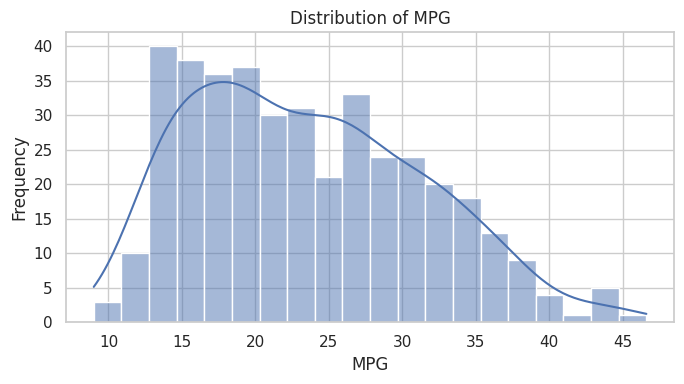

In [72]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x='mpg',
    bins=20,
    kde=True
)

plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

각 변수의 전체 분포 확인

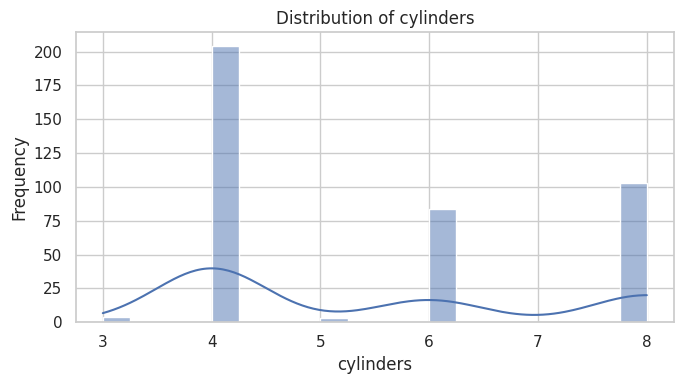

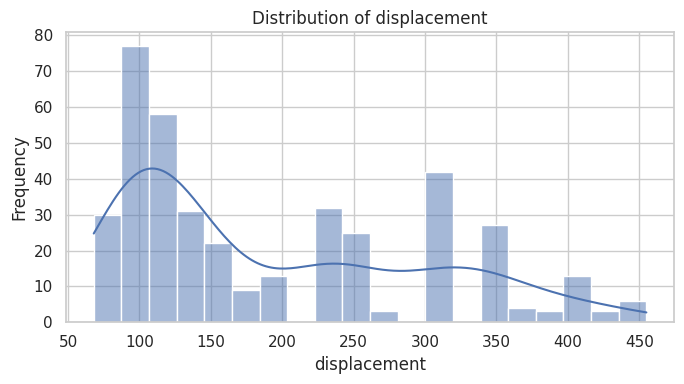

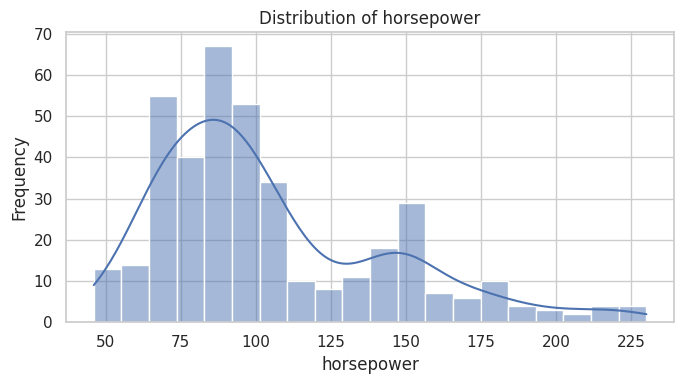

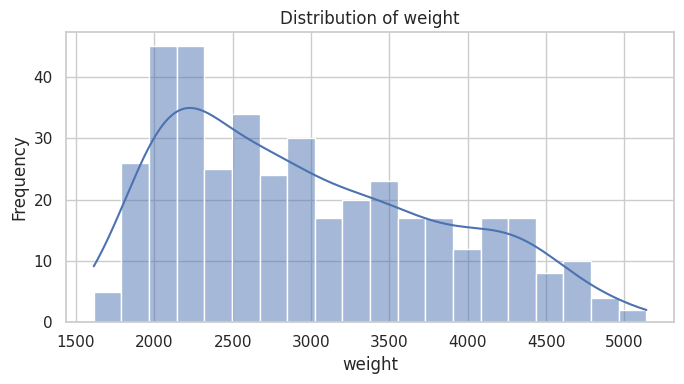

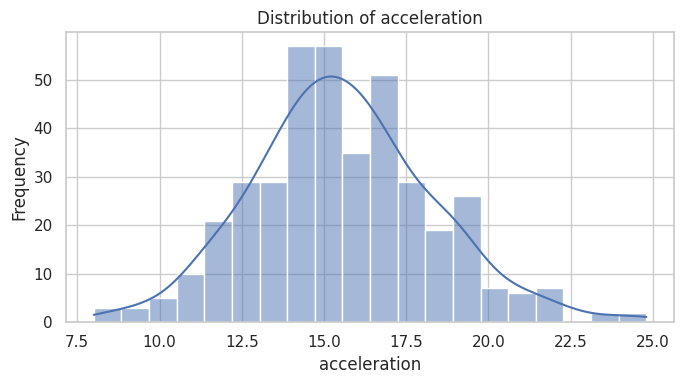

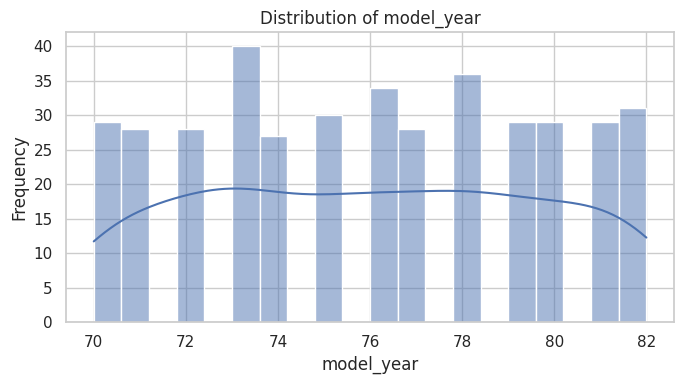

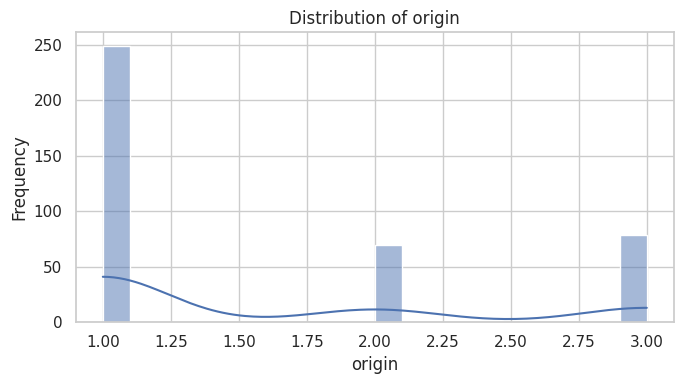

In [73]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

변수별 Box Plot

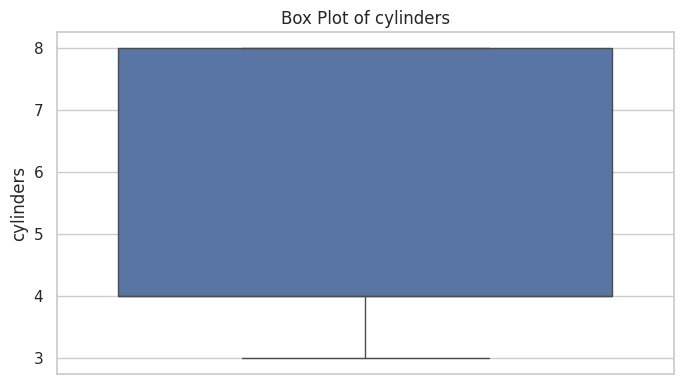

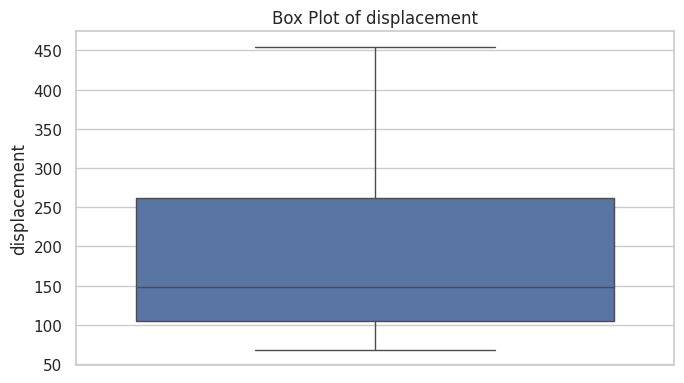

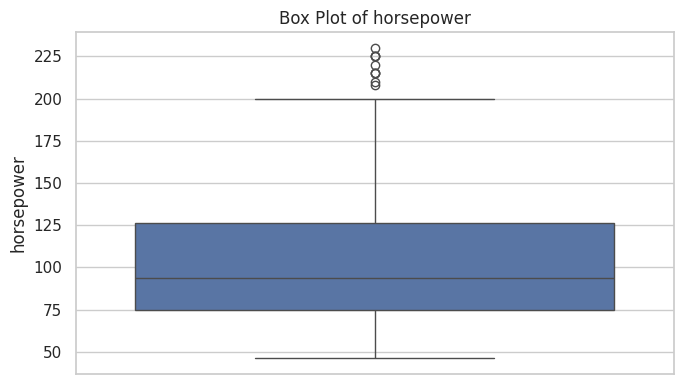

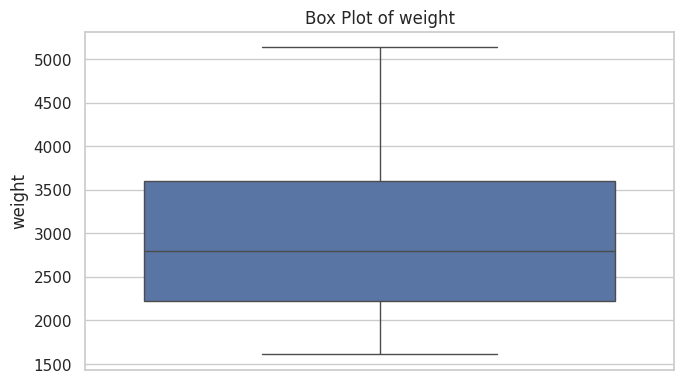

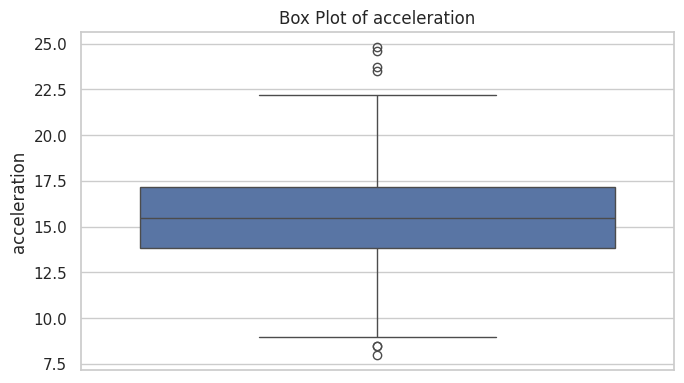

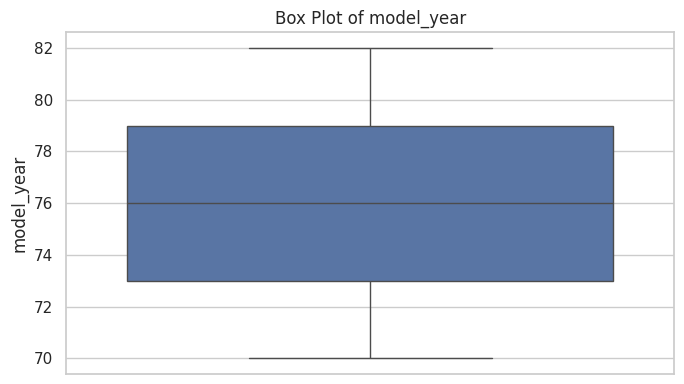

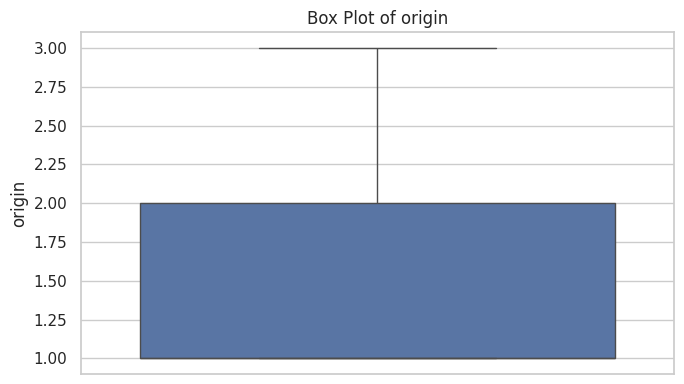

In [74]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        y=col
    )

    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

변수별 Violin Plot

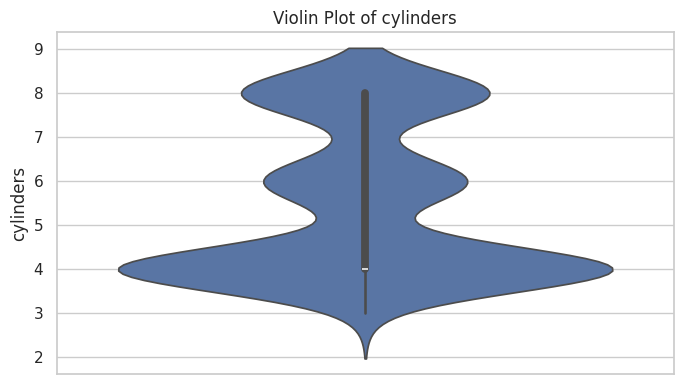

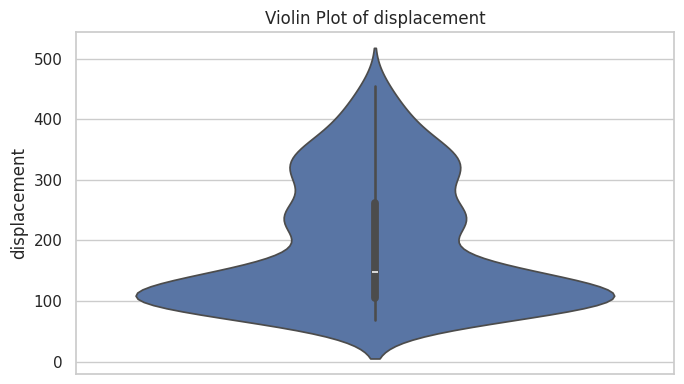

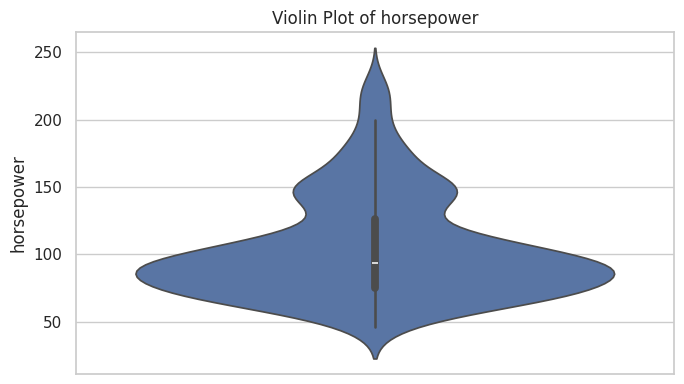

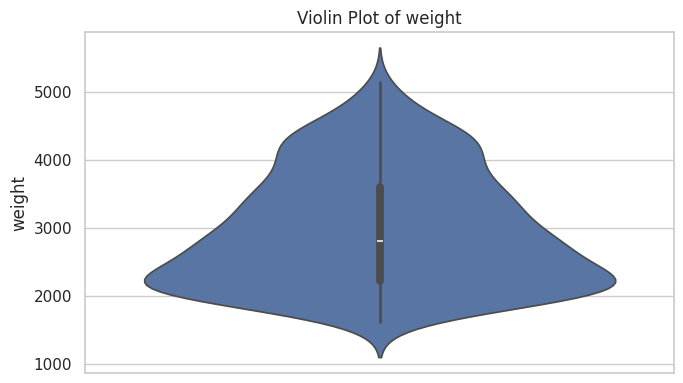

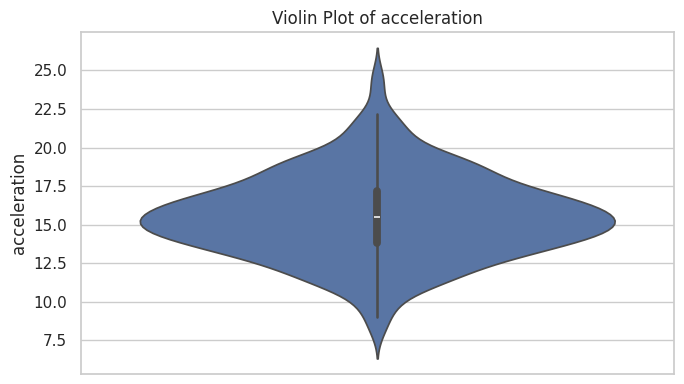

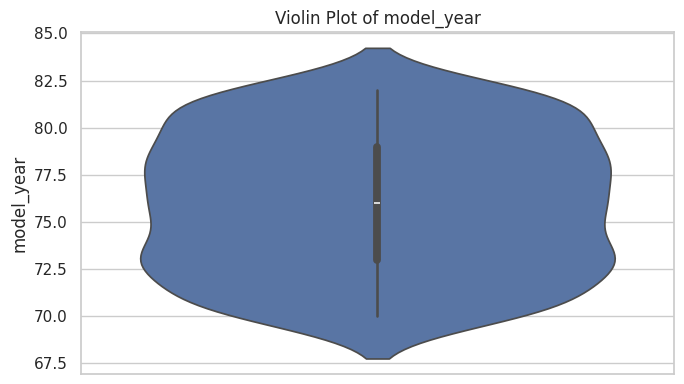

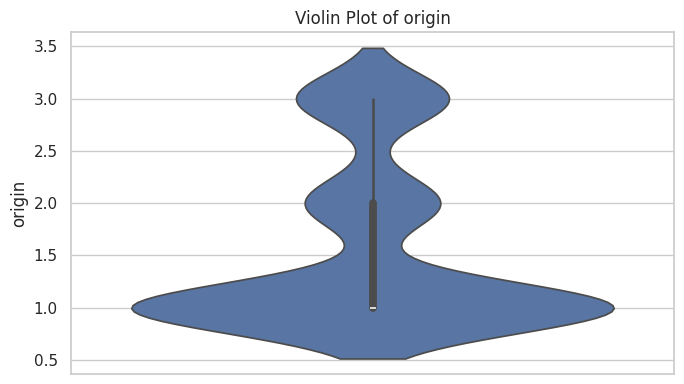

In [75]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.violinplot(
        data=df,
        y=col
    )

    plt.title(f"Violin Plot of {col}")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

Pair Plot

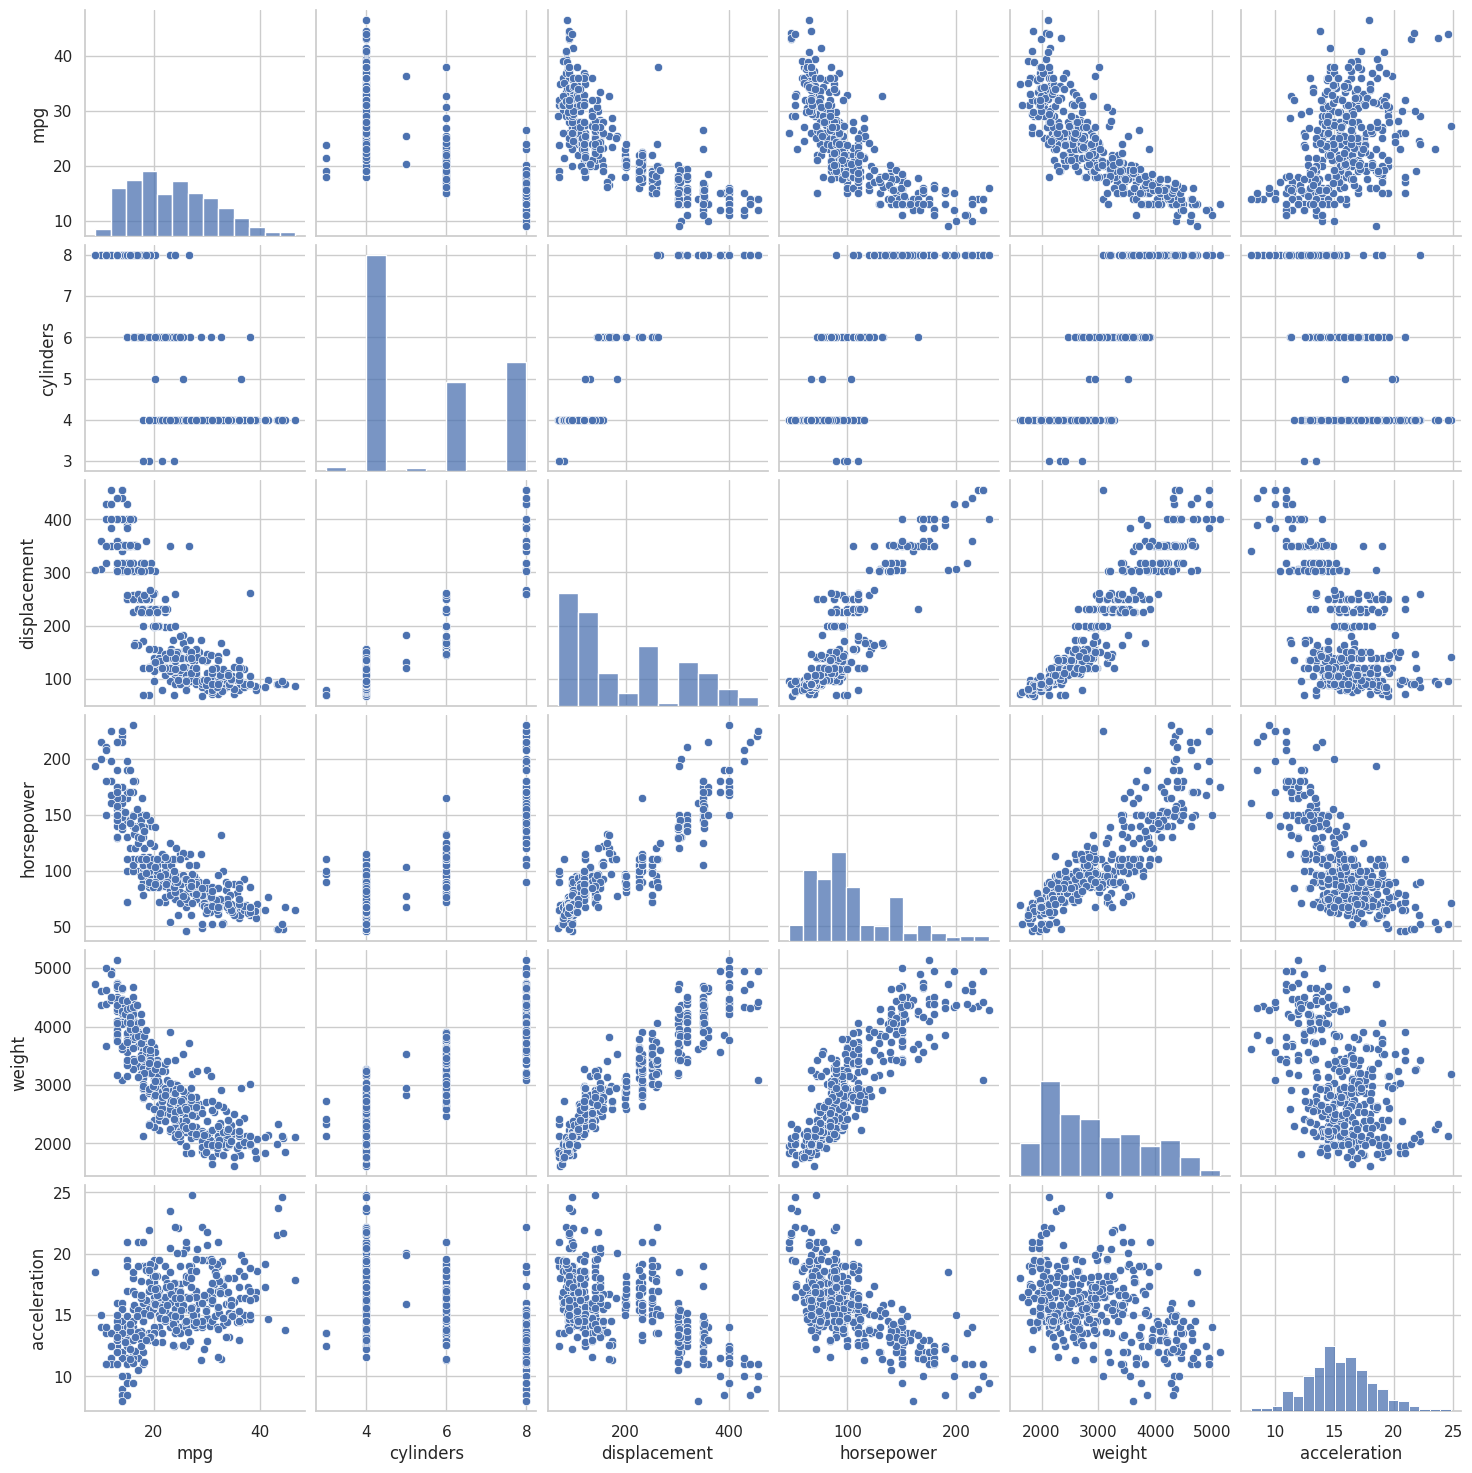

In [76]:
pair_cols = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration'
]

sns.pairplot(
    df[pair_cols],
    diag_kind='hist'
)

plt.show()

변수 간 상관관계 분석

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
cylinders,1.000,0.951,0.843,0.896,-0.505,-0.349,-0.563
displacement,0.951,1.000,0.897,0.933,-0.544,-0.370,-0.609
horsepower,0.843,0.897,1.000,0.865,-0.689,-0.416,-0.455
weight,0.896,0.933,0.865,1.000,-0.417,-0.307,-0.581
acceleration,-0.505,-0.544,-0.689,-0.417,1.000,0.288,0.206
model_year,-0.349,-0.370,-0.416,-0.307,0.288,1.000,0.181
origin,-0.563,-0.609,-0.455,-0.581,0.206,0.181,1.000


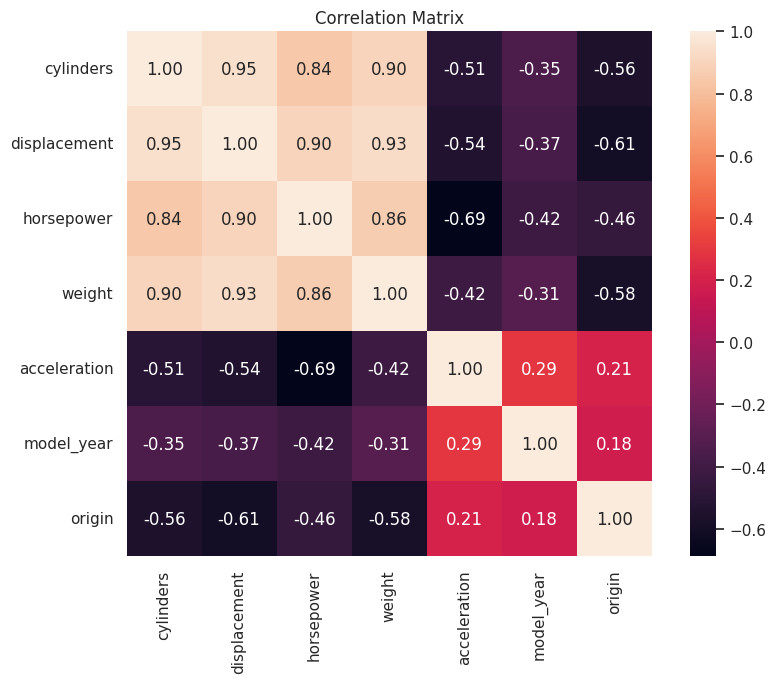

In [77]:
corr = df[numeric_cols].corr()

display(corr.round(3))
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

MPG와 주요 변수의 관계

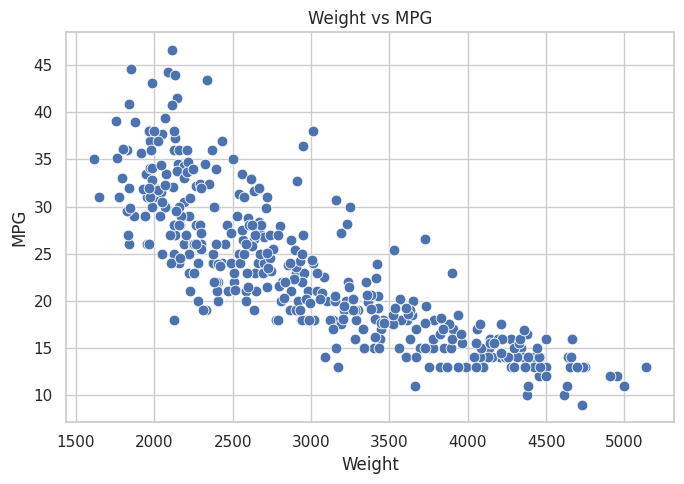

In [78]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='weight',
    y='mpg',
    s=60
)

plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()

MPG vs Horsepower

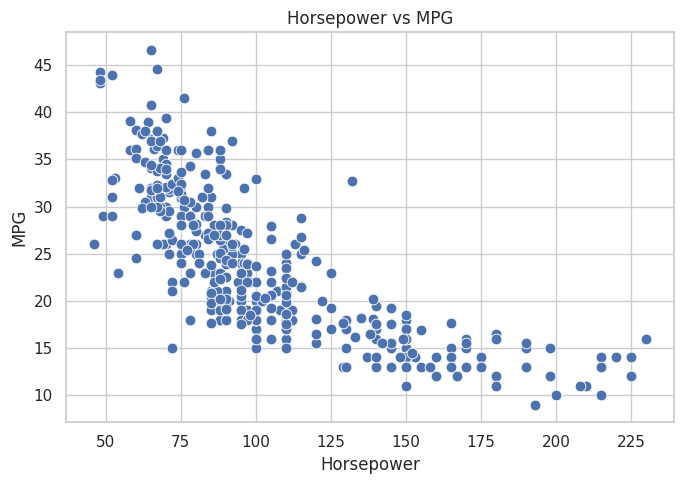

In [79]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='horsepower',
    y='mpg',
    s=60
)

plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()

MPG vs Displacement

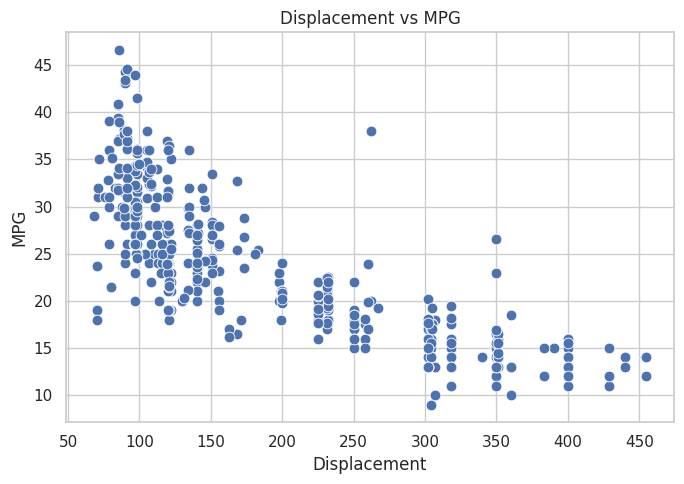

In [80]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='displacement',
    y='mpg',
    s=60
)

plt.title("Displacement vs MPG")
plt.xlabel("Displacement")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()

IQR을 이용한 이상치 탐지

In [81]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col:20s} : "
        f"{len(outliers)}개 "
        f"(Lower={lower:.2f}, Upper={upper:.2f})"
    )

cylinders            : 0개 (Lower=-2.00, Upper=14.00)
displacement         : 0개 (Lower=-132.38, Upper=498.62)
horsepower           : 10개 (Lower=-1.50, Upper=202.50)
weight               : 0개 (Lower=147.38, Upper=5684.38)
acceleration         : 7개 (Lower=8.80, Upper=22.20)
model_year           : 0개 (Lower=64.00, Upper=88.00)
origin               : 0개 (Lower=-0.50, Upper=3.50)


실제 이상치 확인

In [83]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    if len(outliers) > 0:
        print(f"\n[{col} 이상치]")
        display(outliers[[col]])


[horsepower 이상치]


,horsepower
6,220.0
7,215.0
8,225.0
13,225.0
25,215.0
27,210.0
67,208.0
94,215.0
95,225.0
116,230.0



[acceleration 이상치]


,acceleration
7,8.5
9,8.5
11,8.0
59,23.5
299,24.8
326,23.7
394,24.6


Model Year별 평균 MPG

In [84]:
year_mpg = (
    df.groupby('model_year')['mpg']
      .mean()
      .reset_index()
)

display(year_mpg.round(3))

,model_year,mpg
0,70,17.690
1,71,21.250
2,72,18.714
3,73,17.100
4,74,22.704
5,75,20.267
6,76,21.574
7,77,23.375
8,78,24.061
9,79,25.093


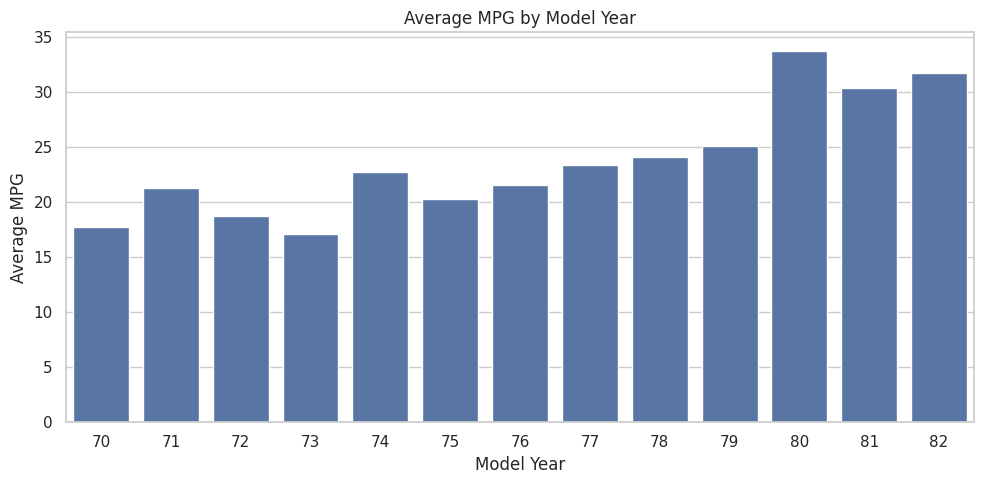

In [85]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=year_mpg,
    x='model_year',
    y='mpg'
)

plt.title("Average MPG by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")

plt.tight_layout()
plt.show()

Origin별 평균 MPG

,origin,mpg
0,1,20.084
1,2,27.891
2,3,30.451


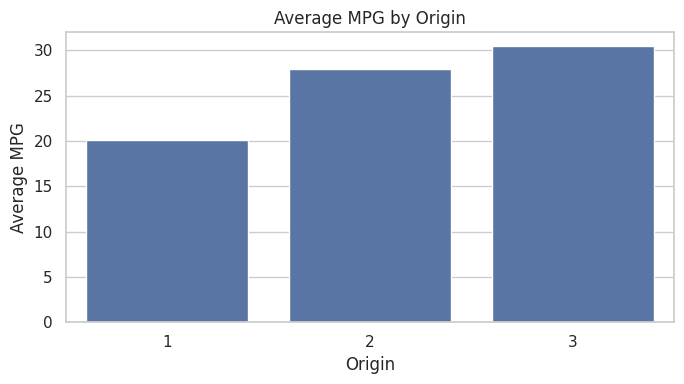

In [87]:
origin_mpg = (
    df.groupby('origin')['mpg']
      .mean()
      .reset_index()
)

display(origin_mpg.round(3))

plt.figure(figsize=(7, 4))

sns.barplot(
    data=origin_mpg,
    x='origin',
    y='mpg'
)

plt.title("Average MPG by Origin")
plt.xlabel("Origin")
plt.ylabel("Average MPG")

plt.tight_layout()
plt.show()

Cylinders별 평균 MPG

,cylinders,mpg
0,3,20.550
1,4,29.287
2,5,27.367
3,6,19.986
4,8,14.963


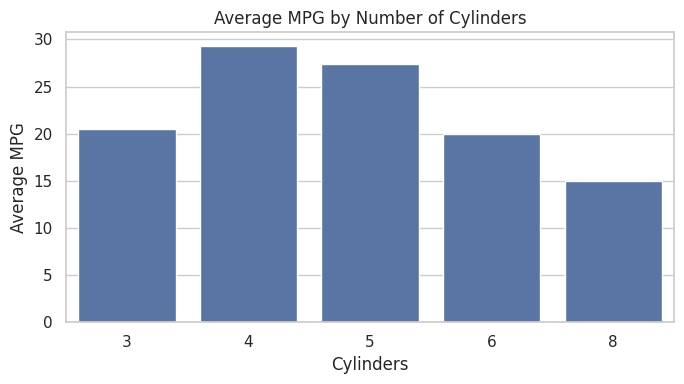

In [88]:
cylinder_mpg = (
    df.groupby('cylinders')['mpg']
      .mean()
      .reset_index()
)

display(cylinder_mpg.round(3))

plt.figure(figsize=(7, 4))

sns.barplot(
    data=cylinder_mpg,
    x='cylinders',
    y='mpg'
)

plt.title("Average MPG by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Average MPG")

plt.tight_layout()
plt.show()

MPG와 Cylinders 관계

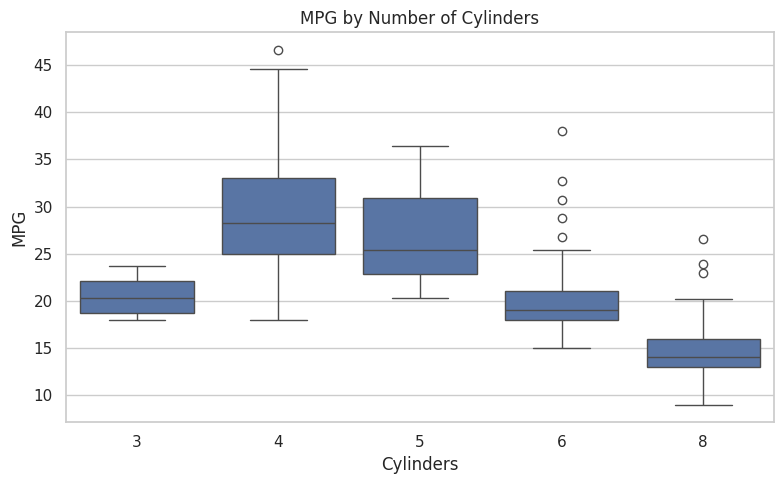

In [89]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='cylinders',
    y='mpg'
)

plt.title("MPG by Number of Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()

변동계수(CV) 확인

,0
displacement,0.539
origin,0.510
horsepower,0.368
cylinders,0.312
weight,0.285
acceleration,0.177
model_year,0.049


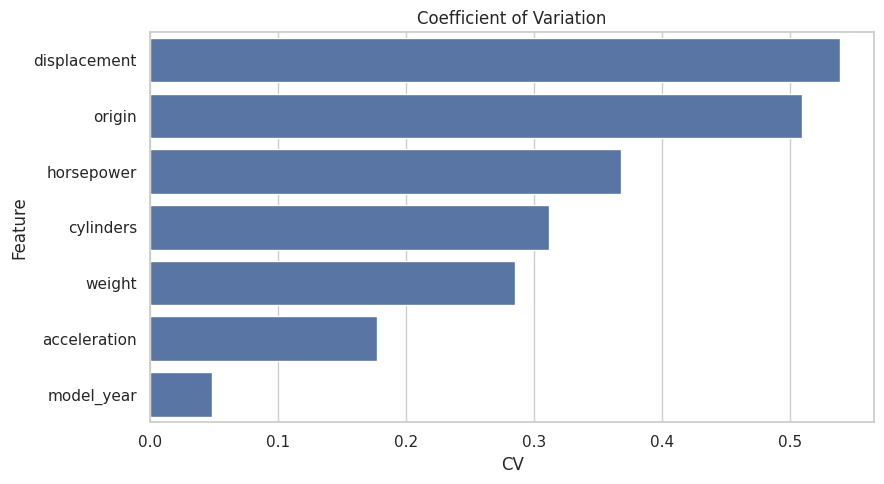

In [90]:
cv = (
    df[numeric_cols].std() /
    df[numeric_cols].mean()
)

cv = cv.sort_values(ascending=False)

display(cv.round(3))

plt.figure(figsize=(9, 5))

sns.barplot(
    x=cv.values,
    y=cv.index
)

plt.title("Coefficient of Variation")
plt.xlabel("CV")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

MPG와 변수들의 상관관계 비교

MPG와 변수들의 상관관계
model_year      0.579267
origin          0.563450
acceleration    0.420289
cylinders      -0.775396
horsepower     -0.778427
displacement   -0.804203
weight         -0.831741
dtype: float64


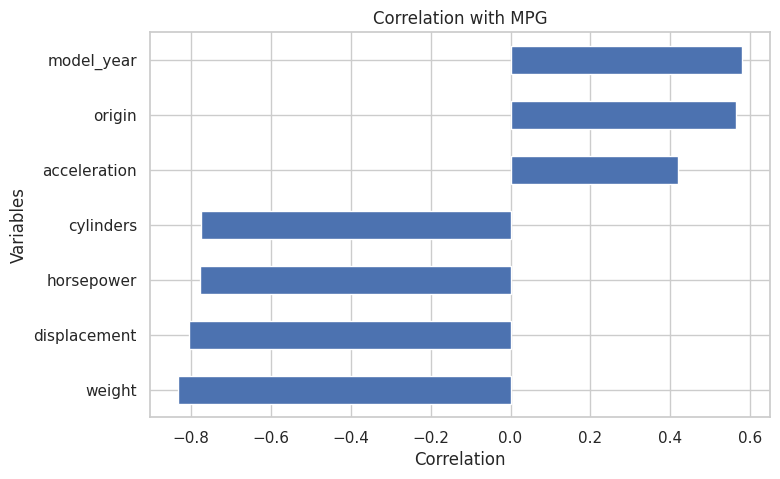

In [92]:
correlations = df[numeric_cols].corrwith(df['mpg'])

print("MPG와 변수들의 상관관계")
print(correlations.sort_values(ascending=False))

plt.figure(figsize=(8, 5))

correlations.sort_values().plot(kind='barh')

plt.title("Correlation with MPG")
plt.xlabel("Correlation")
plt.ylabel("Variables")
plt.show()

MPG와 Weight의 관계를 Model Year별로 비교

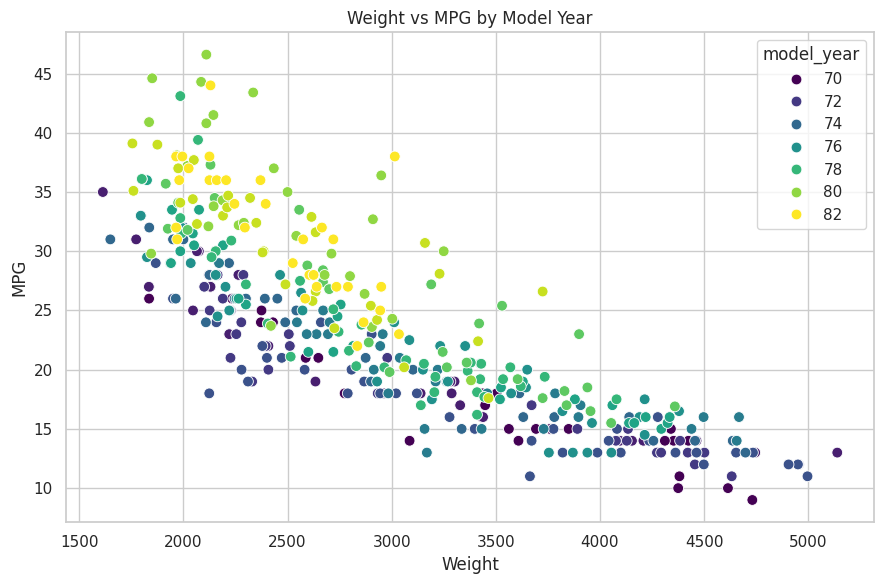

In [93]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='weight',
    y='mpg',
    hue='model_year',
    palette='viridis',
    s=60
)

plt.title("Weight vs MPG by Model Year")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()